# Wstęp
Zadanie 6 stanowi wprowadzenie w tematykę *data augmentation*. Ze względu na złożonośc modeli głębokich, zwykle wymagają one bardzo dużych zbiorów danych do dobrego wyuczenia. Jednym ze sposobów na skalowanie ilości dostępnych danych są metody tzw. augmentacji - przekształcenia na danych które mamy, aby utworzyć nowe przykłady o znanych etykietach. Pod koniec zadania wprowadzona jest również koncepcja *skip connections*, będących istotnym elementem współczesnych architektur konwolucyjnych i nie tylko.

#Cel ćwiczenia

Celem ćwiczenia jest zapoznanie się z

*    koncepcją augmentacji danych
*    implementacją metod augmentacji danych obrazowych w torch.transforms
*    koncepcją augmentacji niezależnej od dziedziny
*    modelami sieci głębokich ze skip connections

#Augmentacja danych obrazowych

W pierwszej kolejności zapoznajmy się z funkcjonalnością augmentacji danych obrazowych. W pytorch funkcjonalność ta realizowana jest przez transformacje wykonywane na obrazach przez `torchvision.transforms`.

Transformacje które typowo wykorzystuje się w augmentacji to standardowe przekształcenia afiniczne obrazu - rotacje, dobicia, skalowanie. Oczywiście, pownniśmy dobierać transformacje z takich, po których rzeczywiście oczekujemy inwariancji - przekształcony obraz będziemy podawać do sieci z tą samą etykietą. Przykładowo, na zbiorze odręcznie pisanych cyfr MNIST ograniczymy zakres obrotów czy wykorzystanie odbicia w osi poziomej, jako że niechcemy pomylić 5 z 2 czy 6 z 9.

Zapoznaj się z dokumentacją transforms tutaj:

https://pytorch.org/vision/stable/transforms.html

Kod poniżej wczytuje CIFAR 10 i pokazuje wyniki przykładowej augmentacji - losowej rotacji o kąt -30 do 30 stopni.

In [1]:
import torchvision

/home/kociecki/repos/studia/deep-neural-network-pwr/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


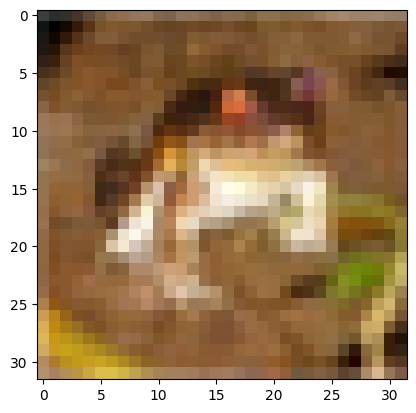

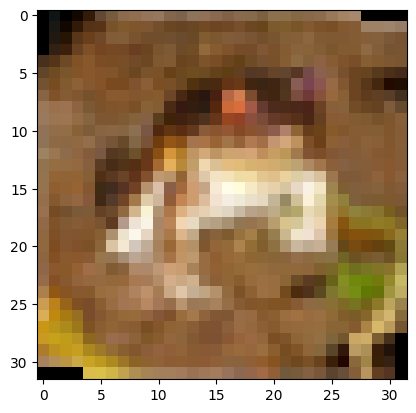

In [2]:
import torch
import torchvision.transforms as transforms
from matplotlib import pyplot as plt


transform = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.ToTensor()
])

train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, download=True)
img, label = train_ds[0]

plt.imshow(img.permute(1,2,0))
plt.show()

img, label = train_ds[0]

plt.imshow(img.permute(1,2,0))
plt.show()

Widzimy tutaj kolejny potencjalny problem z augmentacjami: ze względu na konieczność utrzymania stałego kształtu wejścia, augmentacje mogą wprowadzać artefakty takie jak czarne fragmenty na krawędziach obrazu czy aliasing wynikający z niskiej rozdzielczości.

Poniżej kod pomocniczy z laboratorium 3, można zastąpić go własną implementacją pętli uczącej uwzględniającej ulepszenia wykonane na laboratoriach 4 i 5. W zadaniach poniżej wystarczy porównać końcowy wynik uczenia, nie jest wymagane wyrysowywanie pełnych krzywych w tensorboard niemniej mogą one pomóc w analizie otrzymanych wyników.

In [8]:
import torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from torch.utils.data import DataLoader
from typing import Tuple
from tqdm import tqdm
import mlflow
import mlflow.pytorch
mlflow.set_tracking_uri("sqlite:///mlflow.db")
transform = torchvision.transforms.ToTensor()

train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, download=True)
test_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, train=False, download=True)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=32, pin_memory=True)

def count_correct(y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
    preds = torch.argmax(y_pred, dim=1)
    return (preds == y_true).float().sum()

def validate(
    model: nn.Module, loss_fn: torch.nn.CrossEntropyLoss, dataloader: DataLoader
) -> Tuple[torch.Tensor, torch.Tensor]:
    loss = 0
    correct = 0
    all_samples = 0
    for X_batch, y_batch in dataloader:
        y_pred = model(X_batch)
        all_samples += len(y_pred)
        loss += loss_fn(y_pred, y_batch).sum()
        correct += count_correct(y_pred, y_batch)
    return loss / all_samples, correct / all_samples

def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    print_metrics: bool = True,
    run_name: str = "Default_Run",
    log_params: dict = None
):
    with mlflow.start_run(run_name=run_name):
        
        mlflow.log_param("epochs", epochs)
        if log_params:
            mlflow.log_params(log_params)

        for epoch in range(epochs):
            model.train()
            for X_batch, y_batch in tqdm(train_dl, desc=f"Epoka {epoch}/{epochs-1}"):
                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)

                loss.backward()
                optimiser.step()
                optimiser.zero_grad()

            if print_metrics:
                model.eval()
                with torch.no_grad():
                    train_loss, train_acc = validate(model, loss_fn, train_dl)
                    val_loss, val_acc = validate(model, loss_fn, val_dl)
                    
                    print(
                        f"Epoch {epoch}: "
                        f"train loss = {train_loss:.3f} (acc: {train_acc:.3f}), "
                        f"val loss = {val_loss:.3f} (acc: {val_acc:.3f})"
                    )

                    mlflow.log_metric("train_loss", train_loss.item(), step=epoch)
                    mlflow.log_metric("train_acc", train_acc.item(), step=epoch)
                    mlflow.log_metric("val_loss", val_loss.item(), step=epoch)
                    mlflow.log_metric("val_acc", val_acc.item(), step=epoch)
                    
        mlflow.pytorch.log_model(model, f"model_{run_name}")

# Zadanie 1

Wykorzystując klasę ThreeLayerCNN z `channels=32`, spróbuj dobrać augmentacje danych tak aby poprawić wyniki względem jej braku na zbiorze CIFAR10.

In [9]:
class ThreeLayerCNN(torch.nn.Module):
  def __init__(self, channels: int, labels: int):
    super().__init__()
    self.model = torch.nn.Sequential()
    self.model.add_module("in_conv",
                          torch.nn.Conv2d(3, channels, 1))
    self.model.add_module("relu_1", torch.nn.ReLU())
    self.model.add_module("conv_1",
                          torch.nn.Conv2d(channels, channels, 3, padding=1))
    self.model.add_module("relu_2", torch.nn.ReLU())
    self.model.add_module("max_pool_1", torch.nn.MaxPool2d(2))
    self.model.add_module("conv_2",
                          torch.nn.Conv2d(channels, channels, 3, padding=1))
    self.model.add_module("relu_3", torch.nn.ReLU())
    self.model.add_module("max_pool_2", torch.nn.MaxPool2d(2))
    self.model.add_module("flatten", torch.nn.Flatten())
    self.model.add_module("linear", torch.nn.Linear(channels * 8 * 8, labels)) #uzupełnij

  def forward(self, x):
    return self.model(x)

Zaprogramuj eksperyment tak, aby w pętli sprawdzać kolejne potencjalne wersje potoku przetwarzania (różniące się tutaj tylko augmentacją), a na końcu wybrać najlepszą - tak aby możliwe było powtórzenie całego eksperymentu uzasadniającego wybór! Transformacja z augmentacją ma być wywoływana tylko na danych treningowych.

Spróbuj znaleźć również przykład augmentacji pogarszającej wynik w stosunku do bazowego otrzymanego bez augmentacji. Wykorzystaj uczenie na 50 epok i optymalizator Adam z domyślnymi parametrami, bez regularyzacji.

In [10]:
transformations = {
    "baseline": transforms.Compose([
        transforms.ToTensor()
    ]),

    "horizontal_flip_crop": transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor()
    ]),

    "color_jitter": transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor()
    ]),

    "rotation_15deg": transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor()
    ]),

    "heavy_composite": transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)) 
    ]),

    "vertical_flip_only": transforms.Compose([
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor()
    ]),

    "gaussian_blur": transforms.Compose([
        transforms.GaussianBlur(kernel_size=11, sigma=(2.0, 3.0)),
        transforms.ToTensor()
    ])
}

epochs = 50

In [ ]:
import torchvision.transforms as transforms



for name, train_transform in transformations.items():
    print(f"Starting: {name}")

    train_ds_aug = torchvision.datasets.CIFAR10("cifar_root", transform=train_transform, train=True, download=True)
    train_dl_aug = DataLoader(train_ds_aug, batch_size=32, shuffle=True, pin_memory=True)
    
    model = ThreeLayerCNN(channels=32, labels=10)
    loss_fn = nn.CrossEntropyLoss()
    optimiser = optim.Adam(model.parameters())
    
    fit(
        model=model,
        optimiser=optimiser,
        loss_fn=loss_fn,
        train_dl=train_dl_aug, 
        val_dl=test_dl,       
        epochs=epochs,
        print_metrics=True,
        run_name=f"Augmentacja_{name}",
        log_params={"augmentation_type": name, "optimizer": "Adam"}
    )

# Mixup - augmentacja ogólna

Augmentacja daje nam spore możliwości w sytuacji, gdy w dziedzinie danych jesteśmy w stanie wskazać przekształcenia na kóre nasz model powinien być **inwariantny** - dla obrazków niewielkie skalowanie czy przesunięcie nie powinno zmieniać wyniku, zaś dla tekstu, podstawianie synonimów może spełniać podobną rolę. Ale w augmentacji danych możliwe jest też podejście niezależne od typu danych, wynikające z obserwacji dotyczących dynamiki uczenia sieci głębokich w ogóle. Ciekawym przykładem jest tu augmentacja Mixup:

https://arxiv.org/abs/1710.09412

Zasada działania mixup jest niezwykle prosta - generujemy nowe przykłady jako **kombinacje liniowe** tych istniejących w zbiorze danych i oczekujemy, że ich etykiety również będą kombinacjami liniowymi etykiet. Innymi słowy, dla pary przykładów z etykietami: $(x_1, y_1)$, $(x_2, y_2)$, możemy wygenerować przykład $(x', y')$:

$x' = \lambda x_1 + (1-\lambda) x_2$

$y' = \lambda y_1 + (1-\lambda) y_2$

Wartość $\lambda$ jest tutaj losowana z rozkładu Beta - animacja podana na https://en.wikipedia.org/wiki/Beta_distribution#Definitions dobrze obrazuje, jak wygląda ten rozkład dla różnych parametryzacji.

# Zadanie 2

Zmodyfikuj funkcję fit tak, aby uczyć zgodnie z podanym wyżej sformułowaniem augmentacji Mixup. (Pamiętaj, że model musi przyjmować etykiety w postaci kombinacji dwóch klas. Będzie to wymagało modyfikacji funkcji kosztu! )

In [11]:
import numpy as np
import mlflow
import mlflow.pytorch

def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    print_metrics: bool = True,
    run_name: str = "Mixup_Run",
    alpha: float = 0.2 # Parametr rozkładu Beta dla Mixup
):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("alpha", alpha)
        mlflow.log_param("augmentation", "Mixup")

        for epoch in range(epochs):
            model.train()
            for X_batch, y_batch in tqdm(train_dl, desc=f"Epoka {epoch}/{epochs-1}"):

                # 1. Losowanie lambdy z rozkładu Beta
                if alpha > 0:
                    lam = np.random.beta(alpha, alpha)
                else:
                    lam = 1.0
                
                # 2. Mieszanie obrazów wewnątrz batcha (losowe przetasowanie indeksów)
                index = torch.randperm(X_batch.size(0))
                mixed_x = lam * X_batch + (1 - lam) * X_batch[index, :]
                
                # 3. Zachowanie etykiet dla obu obrazów z pary
                y_a, y_b = y_batch, y_batch[index]

                # 4. Predykcja i obliczenie "zmixowanej" straty
                y_pred = model(mixed_x)
                loss = lam * loss_fn(y_pred, y_a) + (1 - lam) * loss_fn(y_pred, y_b)

                loss.backward()
                optimiser.step()
                optimiser.zero_grad()

            if print_metrics:
                model.eval()
                with torch.no_grad():
                    train_loss, train_acc = validate(
                        model=model, loss_fn=loss_fn, dataloader=train_dl
                    )
                    val_loss, val_acc = validate(
                        model=model, loss_fn=loss_fn, dataloader=val_dl
                    )
                    print(
                        f"Epoch {epoch}: "
                        f"train loss = {train_loss:.3f} (acc: {train_acc:.3f}), "
                        f"validation loss = {val_loss:.3f} (acc: {val_acc:.3f})"
                    )
                    
                    mlflow.log_metric("train_loss", train_loss.item(), step=epoch)
                    mlflow.log_metric("train_acc", train_acc.item(), step=epoch)
                    mlflow.log_metric("val_loss", val_loss.item(), step=epoch)
                    mlflow.log_metric("val_acc", val_acc.item(), step=epoch)
                    
        mlflow.pytorch.log_model(model, f"model_{run_name}")

Sprawdź, czy uzyskuje ona przewagę nad modelem trenowanym bez augmentacji.



In [7]:
model_mixup = ThreeLayerCNN(channels=32, labels=10)
loss_fn = nn.CrossEntropyLoss()
optimiser = optim.Adam(model_mixup.parameters())

fit(
    model=model_mixup,
    optimiser=optimiser,
    loss_fn=loss_fn,
    train_dl=train_dl, 
    val_dl=test_dl,
    epochs=50,
    print_metrics=True,
    run_name="Augmentacja_Mixup",
    alpha=0.2
)

Epoka 0/49:   0%|          | 0/1563 [00:00<?, ?it/s]/home/kociecki/repos/studia/deep-neural-network-pwr/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoka 0/49: 100%|██████████| 1563/1563 [01:32<00:00, 16.84it/s]


Epoch 0: train loss = 0.043 (acc: 0.523), validation loss = 0.043 (acc: 0.515)


Epoka 1/49: 100%|██████████| 1563/1563 [01:13<00:00, 21.17it/s]


Epoch 1: train loss = 0.038 (acc: 0.574), validation loss = 0.039 (acc: 0.559)


Epoka 2/49: 100%|██████████| 1563/1563 [01:10<00:00, 22.26it/s]


...

Epoch 47: train loss = 0.020 (acc: 0.802), validation loss = 0.029 (acc: 0.689)


Epoka 48/49: 100%|██████████| 1563/1563 [01:10<00:00, 22.16it/s]


Epoch 48: train loss = 0.019 (acc: 0.798), validation loss = 0.029 (acc: 0.688)


Epoka 49/49: 100%|██████████| 1563/1563 [01:12<00:00, 21.63it/s]
2026/04/15 00:40:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 00:40:55 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Epoch 49: train loss = 0.020 (acc: 0.792), validation loss = 0.029 (acc: 0.692)


# Skrótowe połączenia

W kontekście sieci konwolucyjnych warto zpoznać się jeszcze z jedną istotną koncepcją: połączenia omijające warstwy, poprzez konkatenacje ich wyniku z wynikami dalszych warstw lub dodawanie ich wyniku do wyjścia dalszej warstwy (w drugim przypadku mówimy też o połączeniach *rezydualnych*). Połączenia takie są potrzebne szczególnie przy trenowaniu sieci bardzo głębokich, zawierających dziesiątki czy nawet ponad 100 warstw, czego nie będziemy w stanie realistycznie zrealizować w czasie naszych laboratoriów. Niemniej warto zapoznać się zarówno z samą ideą, jak i ich implementacją, jako że przy pracy z architekturami *state of the art* będziemy często natykać się na takie konstrukcje.

W konstrukcji sieci z połączeniamy pomijającymi warstwy i połączeniami rezydualnymi często będziemy spotykać się z powtarzalnymi *blokami* obejmującymi kilka warstw - dobrą praktyką implementacyjną jest wydzielanie takich bloków jako osobnych podklas `torch.nn.Module`. Warto też z góry zwrócić uwagę, że znane nam już `torch.nn.Sequential` nie uwzględnia połączeń innych niż sekwencyjne - czyli połączenia rezydualne i omijanie warstw nie wchodzi w grę, chyba że w obrębie wydzielonego bloku.

# Zadanie 3

Uzupełnij kod klasy SkipBlock tak, aby implementowała blok o zadanej strukturze.

Struktura SkipBlock:


*  zadana liczba `n` warstw konwolucyjnch, `channels x channels` kanałów, filtr 3x3, padding 1
*  aktywacja ReLU po każdej warstwie
*  pooling 2x pod koniec całego bloku
*  parametr `skip`: jeśli jest ustawiony na `true`, do wyjścia po ReLU należy **dodać** pierwotne wejście do warstwy konwolucyjnej, jeśli `false` mamy zwyczajną sekwencję warstw konwolucyjnych z aktywacjami

(Dla `skip=false` i `n=1` struktura sieci powinna odpowiadać ThreeLayerCNN powyżej.)

In [12]:
class SkipBlock(torch.nn.Module): # Dodano brakujący dwukropek
  def __init__(self, channels: int, n: int, skip: bool): # Zmodyfikowana sygnatura dla wygody
    super().__init__()
    self.skip = skip
    self.layers = torch.nn.Sequential()
    
    # zadana liczba n warstw konwolucyjnch, channels x channels kanałów, filtr 3x3, padding 1
    # aktywacja ReLU po każdej warstwie
    for i in range(n):
        self.layers.add_module(f"conv_{i}", torch.nn.Conv2d(channels, channels, kernel_size=3, padding=1))
        self.layers.add_module(f"relu_{i}", torch.nn.ReLU())
        
    # pooling 2x pod koniec całego bloku
    self.pool = torch.nn.MaxPool2d(2)

  def forward(self, x):
    out = self.layers(x)
    if self.skip:
        out = out + x # dodanie pierwotnego wejścia do wyjścia warstw konwolucyjnych
    return self.pool(out)


class SkipBlockCNN(torch.nn.Module):
  def __init__(self, channels: int, labels: int, n:int, skip: bool):
    super().__init__()
    self.model = torch.nn.Sequential()
    
    # Warstwa wejściowa transformująca z 3 kanałów RGB na zadaną liczbę kanałów 
    # (dodajemy relu, żeby było spójne z wejściem do bloków)
    self.model.add_module("in_conv", torch.nn.Sequential(
        torch.nn.Conv2d(3, channels, 3, padding=1),
        torch.nn.ReLU()
    ))
    
    # Poprawiono błąd składniowy z wywołaniem parametrów
    self.model.add_module("skip_1", SkipBlock(channels=channels, n=n, skip=skip))
    self.model.add_module("skip_2", SkipBlock(channels=channels, n=n, skip=skip))
    
    self.model.add_module("flatten", torch.nn.Flatten())
    
    # Obraz wejściowy to 32x32. Mamy 2 bloki SkipBlock, każdy z MaxPool2d(2).
    # 32 -> 16 -> 8. Wymiar po spłaszczeniu to channels * 8 * 8.
    self.model.add_module("linear", torch.nn.Linear(channels * 8 * 8, labels)) 

  def forward(self, x):
    return self.model(x)

 Wyucz sieć SkipBlockCNN i porównaj jej wyniki z wcześniej uzykanymi. Porównaj wyniki w zależności od tego, czy włączone są skip connections.

In [13]:
# wyucz sieć i porównaj wyniki

epochs = 50
for skip_val in [False, True]:
    print(f"\nUruchamianie SkipBlockCNN z opcją skip = {skip_val}")
    
    model_skip = SkipBlockCNN(channels=32, labels=10, n=3, skip=skip_val)
    loss_fn = nn.CrossEntropyLoss()
    optimiser = optim.Adam(model_skip.parameters())
    
    fit(
        model=model_skip,
        optimiser=optimiser,
        loss_fn=loss_fn,
        train_dl=train_dl,
        val_dl=test_dl,
        epochs=epochs,
        print_metrics=True,
        run_name=f"SkipConnections_{skip_val}",
        alpha=0.0 # Wyłączamy Mixup dla czystego porównania architektury
    )


Uruchamianie SkipBlockCNN z opcją skip = False


Epoka 0/49:   0%|          | 0/1563 [00:00<?, ?it/s]/home/kociecki/repos/studia/deep-neural-network-pwr/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoka 0/49: 100%|██████████| 1563/1563 [02:35<00:00, 10.03it/s]


Epoch 0: train loss = 0.040 (acc: 0.536), validation loss = 0.041 (acc: 0.523)


Epoka 1/49: 100%|██████████| 1563/1563 [02:25<00:00, 10.75it/s]


Epoch 1: train loss = 0.031 (acc: 0.652), validation loss = 0.033 (acc: 0.628)


...

Epoch 47: train loss = 0.007 (acc: 0.915), validation loss = 0.043 (acc: 0.700)


Epoka 48/49: 100%|██████████| 1563/1563 [01:59<00:00, 13.06it/s]


Epoch 48: train loss = 0.009 (acc: 0.891), validation loss = 0.046 (acc: 0.689)


Epoka 49/49: 100%|██████████| 1563/1563 [02:08<00:00, 12.12it/s]
2026/04/15 19:47:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 19:47:57 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Epoch 49: train loss = 0.007 (acc: 0.913), validation loss = 0.043 (acc: 0.697)
